In [1]:
# Setup for Kaggle or Google Colab environments
# Run this cell to install any missing dependencies!
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn mplsoccer tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.1/98.1 kB 3.4 MB/s eta 0:00:00


In [2]:
# -----------------------------------------------------------
# Kaggle / Colab Environment Setup & Core Functions
# -----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from IPython.display import display, HTML
import warnings
warnings.filterwarnings("ignore")

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (20, 6) # wider for 3 subplots

# Configuration Constants
class config:
    ID_COLS = [
        "event_id", "match_id", "season_id",
        "team_id", "team_name", "player_id", "player_name",
        "period", "minute", "second", "play_pattern",
    ]
    RANDOM_STATE = 42
    K_RANGE = range(2, 11)
    KMEANS_N_INIT = 10
    DISTANCE_METRIC = "euclidean"

# -----------------------------------------------------------
# Clustering Functions
# -----------------------------------------------------------
def run_kmeans(X, k, init="k-means++"):
    model = KMeans(
        n_clusters=k,
        init=init,
        random_state=config.RANDOM_STATE,
        n_init=config.KMEANS_N_INIT,
    )
    labels = model.fit_predict(X)
    inertia = model.inertia_
    return labels, inertia, model

def run_kmeans_sweep(X, k_range=config.K_RANGE):
    results = {}
    for k in k_range:
        results[k] = run_kmeans(X, k)
    return results

def describe_centroids(X_unscaled, labels):
    df = X_unscaled.copy()
    df["Cluster"] = labels
    return df.groupby("Cluster").mean()

# -----------------------------------------------------------
# Selection Metrics Functions
# -----------------------------------------------------------
def elbow_curve(X, k_range=config.K_RANGE):
    results = run_kmeans_sweep(X, k_range)
    data = [{"k": k, "inertia": res[1]} for k, res in results.items()]
    return pd.DataFrame(data)

def suggest_k_elbow(curve):
    n_points = len(curve)
    if n_points < 3:
        return curve["k"].iloc[0]

    all_coords = curve[["k", "inertia"]].values
    first_point = all_coords[0]
    last_point = all_coords[-1]

    line_vec = last_point - first_point
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    vec_from_first = all_coords - first_point
    scalar_proj = np.sum(vec_from_first * line_vec_norm, axis=1)

    vec_proj = np.outer(scalar_proj, line_vec_norm)
    vec_to_line = vec_from_first - vec_proj
    dist_to_line = np.linalg.norm(vec_to_line, axis=1)

    best_idx = np.argmax(dist_to_line)
    return int(curve["k"].iloc[best_idx])

def silhouette_by_k(X, k_range=config.K_RANGE):
    results = run_kmeans_sweep(X, k_range)
    data = []
    for k, (labels, inertia, model) in results.items():
        if k > 1:
            score = silhouette_score(X, labels, metric=config.DISTANCE_METRIC)
        else:
            score = -1.0
        data.append({"k": k, "silhouette": score})
    return pd.DataFrame(data)

def gap_statistic(X, k_range=config.K_RANGE, n_refs=5):
    # Convert to numpy for calculations
    X_arr = X.values if isinstance(X, pd.DataFrame) else X

    # Bounding box of original data
    mins = np.min(X_arr, axis=0)
    maxs = np.max(X_arr, axis=0)

    gap_values = []
    for k in k_range:
        _, original_inertia, _ = run_kmeans(X_arr, k)

        ref_inertias = []
        for _ in range(n_refs):
            # Generate uniform random data in bounding box
            random_data = np.random.uniform(mins, maxs, size=X_arr.shape)
            _, ref_inertia, _ = run_kmeans(random_data, k)
            ref_inertias.append(ref_inertia)

        mean_ref_log_inertia = np.mean(np.log(ref_inertias))
        gap = mean_ref_log_inertia - np.log(original_inertia)
        gap_values.append({"k": k, "gap_value": gap})

    return pd.DataFrame(gap_values)

def summarize_k_selection(elbow, silhouette, gap=None):
    df = elbow.merge(silhouette, on="k")
    if gap is not None:
        df = df.merge(gap, on="k")

    best_elbow = suggest_k_elbow(elbow)
    best_silhouette = silhouette["k"].iloc[np.argmax(silhouette["silhouette"].values)]

    suggestions = {
        "k": [best_elbow, best_silhouette],
        "method": ["Elbow (Max dist)", "Silhouette (Max score)"]
    }

    if gap is not None and "gap_value" in gap.columns:
        best_gap = gap["k"].iloc[np.argmax(gap["gap_value"].values)]
        suggestions["k"].append(best_gap)
        suggestions["method"].append("Gap (Max value)")

    print("\nSuggested K by method:")
    for m, k in zip(suggestions["method"], suggestions["k"]):
        print(f" - {m}: k={k}")

    return df

In [4]:
# -----------------------------------------------------------
# Preprocessing Configuration & Logic
# -----------------------------------------------------------

# Configurations
config.HIDDEN_COLS = ["outcome", "statsbomb_xg", "end_location_x", "end_location_y"]
config.NUMERIC_FEATURES = [
    "location_x", "location_y", "distance_to_goal", "angle_to_goal",
    "n_teammates_in_frame", "n_opponents_in_frame", "keeper_x", "keeper_y"
]
config.CATEGORICAL_FEATURES = ["body_part", "technique", "shot_type"]
config.BOOL_FLAGS = ["under_pressure", "first_time", "open_goal", "aerial_won"]

# Load raw dataset (Output from Task 1)
try:
    df = pd.read_csv("extract_feature_worldcup_2018_2022_raw.csv")
except FileNotFoundError:
    print("Local data folder not found. Assuming Kaggle/Colab current directory.")
    df = pd.read_csv("shots_worldcup_2018_2022_raw.csv")  # Kaggle working directory typically

print("Raw shape:", df.shape)

# 1. Split columns
ids = df[config.ID_COLS].copy()
y_hidden = df[config.HIDDEN_COLS].copy()
X = df[config.NUMERIC_FEATURES + config.CATEGORICAL_FEATURES + config.BOOL_FLAGS].copy()

# 2. Impute missing values
if "keeper_x" in X.columns:
    X["keeper_x"] = X["keeper_x"].fillna(120.0)
if "keeper_y" in X.columns:
    X["keeper_y"] = X["keeper_y"].fillna(40.0)
for col in config.BOOL_FLAGS:
    if col in X.columns:
        X[col] = X[col].fillna(0)

# 3. One-hot encoding
X_encoded = pd.get_dummies(X, columns=config.CATEGORICAL_FEATURES, drop_first=False)
for col in config.BOOL_FLAGS:
    if col in X_encoded.columns:
        X_encoded[col] = X_encoded[col].astype(int)
for col in X_encoded.columns:
    if X_encoded[col].dtype == bool:
        X_encoded[col] = X_encoded[col].astype(int)

# 4. Create unscaled, standard-scaled, and robust-scaled versions
X_unscaled = X_encoded.copy()

std_scaler = StandardScaler()
X_std_arr = std_scaler.fit_transform(X_encoded)
X_standard = pd.DataFrame(X_std_arr, columns=X_encoded.columns, index=X_encoded.index)

robust_scaler = RobustScaler()
X_robust_arr = robust_scaler.fit_transform(X_encoded)
X_robust = pd.DataFrame(X_robust_arr, columns=X_encoded.columns, index=X_encoded.index)

# 5. Prepare variables for modeling
X_train_robust = X_robust.copy()
X_train_standard = X_standard.copy()
X_train_unscaled = X_unscaled.copy()

print("Robust Scaled shape:", X_train_robust.shape)
print("Standard Scaled shape:", X_train_standard.shape)
print("Unscaled shape:", X_train_unscaled.shape)

Raw shape: (3200, 30)
Robust Scaled shape: (3200, 27)
Standard Scaled shape: (3200, 27)
Unscaled shape: (3200, 27)


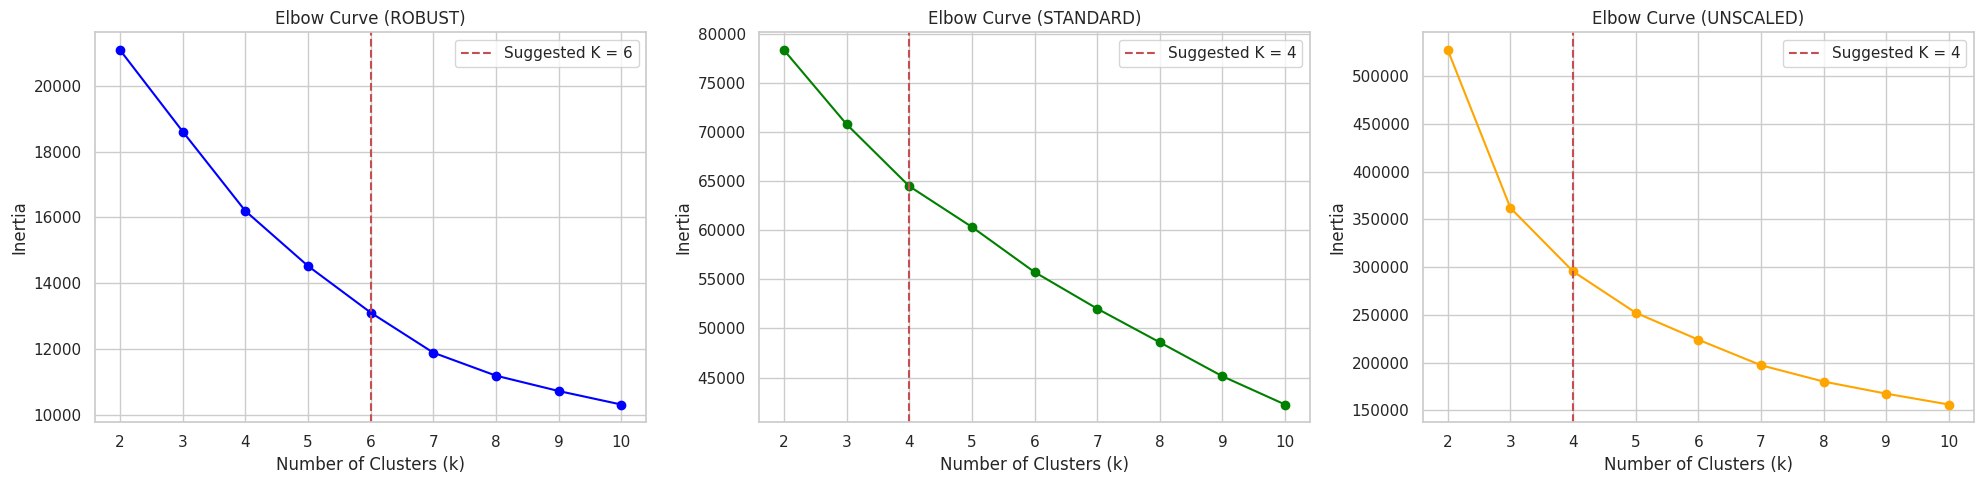

In [5]:
# 1. Elbow Method Comparison
df_elbow_robust = elbow_curve(X_train_robust)
best_k_elbow_robust = suggest_k_elbow(df_elbow_robust)

df_elbow_standard = elbow_curve(X_train_standard)
best_k_elbow_standard = suggest_k_elbow(df_elbow_standard)

df_elbow_unscaled = elbow_curve(X_train_unscaled)
best_k_elbow_unscaled = suggest_k_elbow(df_elbow_unscaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(df_elbow_robust["k"], df_elbow_robust["inertia"], marker="o", linestyle="-", color="blue")
axes[0].axvline(best_k_elbow_robust, color="r", linestyle="--", label=f"Suggested K = {best_k_elbow_robust}")
axes[0].set_title("Elbow Curve (ROBUST)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

axes[1].plot(df_elbow_standard["k"], df_elbow_standard["inertia"], marker="o", linestyle="-", color="green")
axes[1].axvline(best_k_elbow_standard, color="r", linestyle="--", label=f"Suggested K = {best_k_elbow_standard}")
axes[1].set_title("Elbow Curve (STANDARD)")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Inertia")
axes[1].legend()

axes[2].plot(df_elbow_unscaled["k"], df_elbow_unscaled["inertia"], marker="o", linestyle="-", color="orange")
axes[2].axvline(best_k_elbow_unscaled, color="r", linestyle="--", label=f"Suggested K = {best_k_elbow_unscaled}")
axes[2].set_title("Elbow Curve (UNSCALED)")
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("Inertia")
axes[2].legend()

plt.tight_layout()
plt.show()

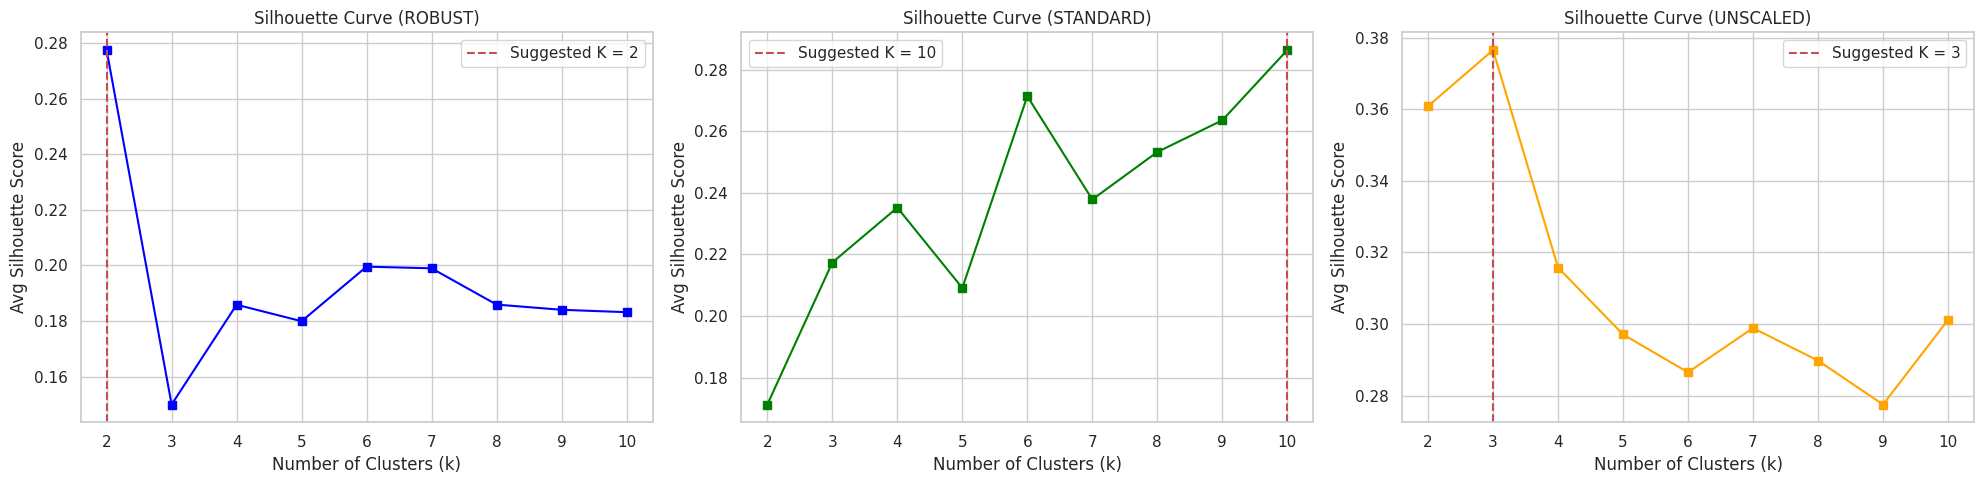

In [6]:
# 2. Silhouette Score Comparison
df_sil_robust = silhouette_by_k(X_train_robust)
best_k_sil_robust = df_sil_robust["k"].iloc[np.argmax(df_sil_robust["silhouette"].values)]

df_sil_standard = silhouette_by_k(X_train_standard)
best_k_sil_standard = df_sil_standard["k"].iloc[np.argmax(df_sil_standard["silhouette"].values)]

df_sil_unscaled = silhouette_by_k(X_train_unscaled)
best_k_sil_unscaled = df_sil_unscaled["k"].iloc[np.argmax(df_sil_unscaled["silhouette"].values)]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(df_sil_robust["k"], df_sil_robust["silhouette"], marker="s", color="blue", linestyle="-")
axes[0].axvline(best_k_sil_robust, color="r", linestyle="--", label=f"Suggested K = {best_k_sil_robust}")
axes[0].set_title("Silhouette Curve (ROBUST)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Avg Silhouette Score")
axes[0].legend()

axes[1].plot(df_sil_standard["k"], df_sil_standard["silhouette"], marker="s", color="green", linestyle="-")
axes[1].axvline(best_k_sil_standard, color="r", linestyle="--", label=f"Suggested K = {best_k_sil_standard}")
axes[1].set_title("Silhouette Curve (STANDARD)")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Avg Silhouette Score")
axes[1].legend()

axes[2].plot(df_sil_unscaled["k"], df_sil_unscaled["silhouette"], marker="s", color="orange", linestyle="-")
axes[2].axvline(best_k_sil_unscaled, color="r", linestyle="--", label=f"Suggested K = {best_k_sil_unscaled}")
axes[2].set_title("Silhouette Curve (UNSCALED)")
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("Avg Silhouette Score")
axes[2].legend()

plt.tight_layout()
plt.show()

Calculating Gap Statistics (this might take a few moments)...


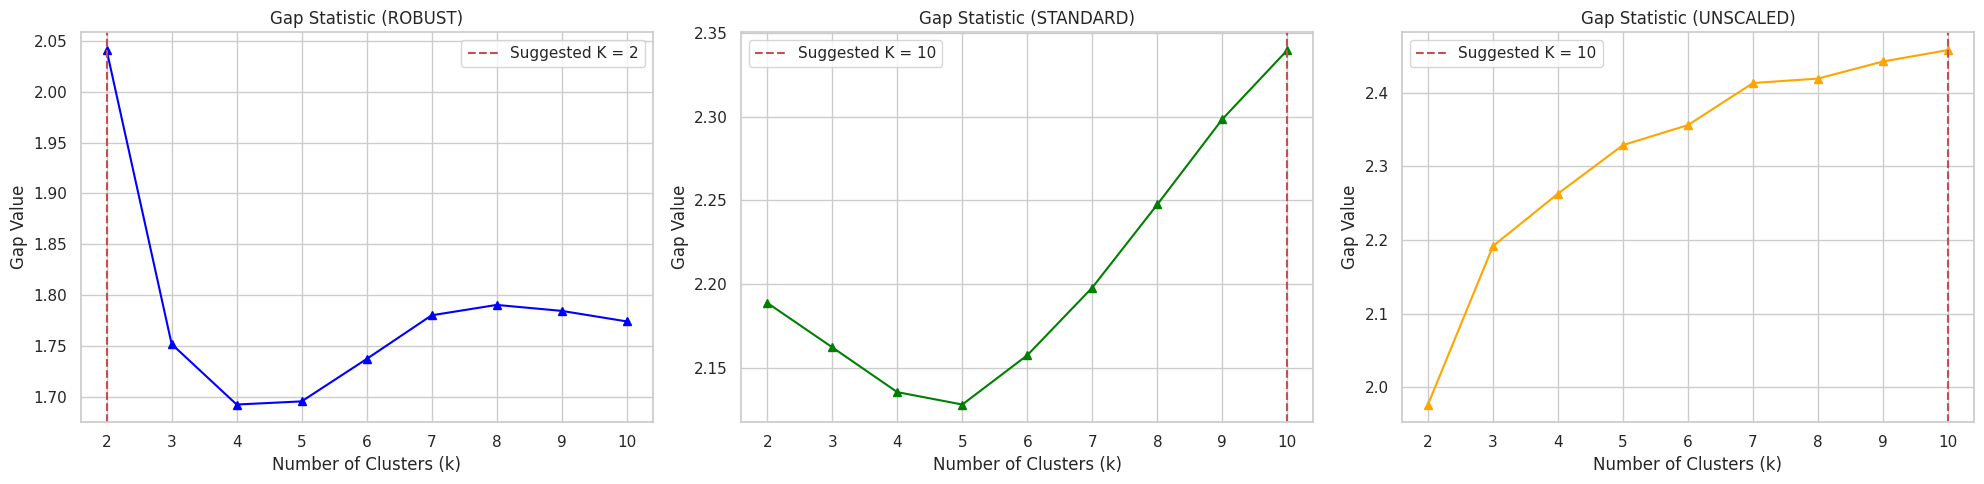

In [7]:
# 3. Gap Statistic Comparison
print("Calculating Gap Statistics (this might take a few moments)...")
df_gap_robust = gap_statistic(X_train_robust)
best_k_gap_robust = df_gap_robust["k"].iloc[np.argmax(df_gap_robust["gap_value"].values)]

df_gap_standard = gap_statistic(X_train_standard)
best_k_gap_standard = df_gap_standard["k"].iloc[np.argmax(df_gap_standard["gap_value"].values)]

df_gap_unscaled = gap_statistic(X_train_unscaled)
best_k_gap_unscaled = df_gap_unscaled["k"].iloc[np.argmax(df_gap_unscaled["gap_value"].values)]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(df_gap_robust["k"], df_gap_robust["gap_value"], marker="^", color="blue", linestyle="-")
axes[0].axvline(best_k_gap_robust, color="r", linestyle="--", label=f"Suggested K = {best_k_gap_robust}")
axes[0].set_title("Gap Statistic (ROBUST)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Gap Value")
axes[0].legend()

axes[1].plot(df_gap_standard["k"], df_gap_standard["gap_value"], marker="^", color="green", linestyle="-")
axes[1].axvline(best_k_gap_standard, color="r", linestyle="--", label=f"Suggested K = {best_k_gap_standard}")
axes[1].set_title("Gap Statistic (STANDARD)")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Gap Value")
axes[1].legend()

axes[2].plot(df_gap_unscaled["k"], df_gap_unscaled["gap_value"], marker="^", color="orange", linestyle="-")
axes[2].axvline(best_k_gap_unscaled, color="r", linestyle="--", label=f"Suggested K = {best_k_gap_unscaled}")
axes[2].set_title("Gap Statistic (UNSCALED)")
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("Gap Value")
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
# Summary Tables
print("=== ROBUST SCALED SUMMARY ===")
summary_robust = summarize_k_selection(df_elbow_robust, df_sil_robust, df_gap_robust)
display(summary_robust)

print("\n=== STANDARD SCALED SUMMARY ===")
summary_standard = summarize_k_selection(df_elbow_standard, df_sil_standard, df_gap_standard)
display(summary_standard)

print("\n=== UNSCALED SUMMARY ===")
summary_unscaled = summarize_k_selection(df_elbow_unscaled, df_sil_unscaled, df_gap_unscaled)
display(summary_unscaled)

=== ROBUST SCALED SUMMARY ===

Suggested K by method:
 - Elbow (Max dist): k=6
 - Silhouette (Max score): k=2
 - Gap (Max value): k=2


,k,inertia,silhouette,gap_value
0,2,21083.399242,0.277455,2.040686
1,3,18609.351325,0.149949,1.752318
2,4,16197.323228,0.185845,1.692992
3,5,14525.838649,0.179915,1.696070
4,6,13111.055661,0.199547,1.737667
5,7,11893.406728,0.198946,1.780517
6,8,11195.011893,0.185897,1.790699
7,9,10728.806644,0.184027,1.784850
8,10,10317.720314,0.183169,1.774522



=== STANDARD SCALED SUMMARY ===

Suggested K by method:
 - Elbow (Max dist): k=4
 - Silhouette (Max score): k=10
 - Gap (Max value): k=10


,k,inertia,silhouette,gap_value
0,2,78338.697679,0.171232,2.188798
1,3,70787.165129,0.217356,2.162200
2,4,64482.362029,0.235193,2.135423
3,5,60333.397124,0.209086,2.128015
4,6,55740.414590,0.271353,2.157491
5,7,52017.763669,0.237831,2.197958
6,8,48586.704290,0.253237,2.247612
7,9,45131.756799,0.263545,2.298599
8,10,42255.522200,0.286354,2.339940



=== UNSCALED SUMMARY ===

Suggested K by method:
 - Elbow (Max dist): k=4
 - Silhouette (Max score): k=3
 - Gap (Max value): k=10


,k,inertia,silhouette,gap_value
0,2,527421.140172,0.360879,1.976732
1,3,362069.110733,0.376545,2.191900
2,4,295579.314056,0.315789,2.263110
3,5,252310.625687,0.297095,2.329043
4,6,224067.327365,0.286506,2.356216
5,7,197359.798442,0.298882,2.413315
6,8,180269.984852,0.289800,2.419362
7,9,167576.513234,0.277514,2.442585
8,10,156225.465631,0.301146,2.458094


In [9]:
# 4. K-Means Centroid Initialization Comparison (k-means++ vs random/forgy)
# We test with K=5 to see differences in performance and inertia
test_k = 5
print(f"Comparing Centroid Initialization for K = {test_k}\n")

def compare_initialization(X, name):
    _, inertia_kmeanspp, model_kmeanspp = run_kmeans(X, k=test_k, init="k-means++")
    _, inertia_random, model_random = run_kmeans(X, k=test_k, init="random")

    print(f"--- {name} Data ---")
    print(f"  k-means++ : Inertia = {inertia_kmeanspp:.2f}, Iterations = {model_kmeanspp.n_iter_}")
    print(f"  random    : Inertia = {inertia_random:.2f}, Iterations = {model_random.n_iter_}\n")

compare_initialization(X_train_robust, "ROBUST SCALED")
compare_initialization(X_train_standard, "STANDARD SCALED")
compare_initialization(X_train_unscaled, "UNSCALED")

Comparing Centroid Initialization for K = 5

--- ROBUST SCALED Data ---
  k-means++ : Inertia = 14525.84, Iterations = 17
  random    : Inertia = 14525.85, Iterations = 34

--- STANDARD SCALED Data ---
  k-means++ : Inertia = 60333.40, Iterations = 13
  random    : Inertia = 60234.77, Iterations = 17

--- UNSCALED Data ---
  k-means++ : Inertia = 252310.63, Iterations = 66
  random    : Inertia = 252310.63, Iterations = 68



In [10]:
# Based on the curves, choose the best K for the branches
def pick_best_k(df_gap, df_sil, df_elbow):
    k1 = df_gap["k"].iloc[np.argmax(df_gap["gap_value"].values)]
    k2 = df_sil["k"].iloc[np.argmax(df_sil["silhouette"].values)]
    k3 = suggest_k_elbow(df_elbow)
    # Most common or just take the max if no consensus
    return int(np.max([k1, k2, k3]))

CHOSEN_K_ROBUST = pick_best_k(df_gap_robust, df_sil_robust, df_elbow_robust)
CHOSEN_K_STANDARD = pick_best_k(df_gap_standard, df_sil_standard, df_elbow_standard)
CHOSEN_K_UNSCALED = pick_best_k(df_gap_unscaled, df_sil_unscaled, df_elbow_unscaled)

print(f"Applying ROBUST SCALED K-Means with K = {CHOSEN_K_ROBUST}")
print(f"Applying STANDARD SCALED K-Means with K = {CHOSEN_K_STANDARD}")
print(f"Applying UNSCALED K-Means with K = {CHOSEN_K_UNSCALED}")

labels_robust, _, model_robust = run_kmeans(X_train_robust, k=CHOSEN_K_ROBUST)
labels_standard, _, model_standard = run_kmeans(X_train_standard, k=CHOSEN_K_STANDARD)
labels_unscaled, _, model_unscaled = run_kmeans(X_train_unscaled, k=CHOSEN_K_UNSCALED)

# Save labels
pd.DataFrame({"cluster_id": labels_robust}).to_csv("labels_robust.csv", index=False)
pd.DataFrame({"cluster_id": labels_standard}).to_csv("labels_standard.csv", index=False)
pd.DataFrame({"cluster_id": labels_unscaled}).to_csv("labels_unscaled.csv", index=False)
print("Saved all labels arrays to local directory.")

Applying ROBUST SCALED K-Means with K = 6
Applying STANDARD SCALED K-Means with K = 10
Applying UNSCALED K-Means with K = 10
Saved all labels arrays to local directory.


In [11]:
# Describe Centroids physically
# Note: X_unscaled has no ID columns, it represents the features used.
X_unscaled_features = X_unscaled.copy()

print("=== ROBUST SCALED CENTROIDS (in original units) ===")
centroids_physical_robust = describe_centroids(X_unscaled_features, labels_robust)
display(centroids_physical_robust)

print("\n=== STANDARD SCALED CENTROIDS (in original units) ===")
centroids_physical_standard = describe_centroids(X_unscaled_features, labels_standard)
display(centroids_physical_standard)

print("\n=== UNSCALED CENTROIDS ===")
centroids_physical_unscaled = describe_centroids(X_unscaled_features, labels_unscaled)
display(centroids_physical_unscaled)

=== ROBUST SCALED CENTROIDS (in original units) ===


,location_x,location_y,distance_to_goal,angle_to_goal,n_teammates_in_frame,n_opponents_in_frame,keeper_x,keeper_y,under_pressure,first_time,...,technique_Diving Header,technique_Half Volley,technique_Lob,technique_Normal,technique_Overhead Kick,technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty
Cluster,,,,,,,,,,,,,,,,,,,,,
0,104.813158,41.510526,16.587443,-0.040303,1.815789,5.368421,106.792105,41.139474,0.131579,0.263158,...,0.000000,0.131579,0.263158,0.552632,0.000000,0.052632,0.000000,0.000000,1.000000,0.000000
1,111.518700,40.079873,9.838436,0.004323,5.464342,9.865293,118.879398,40.310143,0.397781,0.112520,...,0.030111,0.052298,0.001585,0.871632,0.011094,0.026941,0.000000,0.000000,1.000000,0.000000
2,94.557143,39.235115,27.660502,0.026328,6.203926,10.053435,118.341876,40.253435,0.104689,0.218103,...,0.000000,0.117775,0.002181,0.813522,0.002181,0.063250,0.000000,0.137405,0.862595,0.000000
3,108.398507,40.256716,11.647865,-0.022580,0.022388,0.111940,119.972388,40.041045,0.000000,0.007463,...,0.000000,0.007463,0.000000,0.992537,0.000000,0.000000,0.000000,0.000000,0.014925,0.985075
4,106.858311,50.424387,17.633645,-0.670679,3.944142,7.923706,117.747684,42.768120,0.143052,0.400545,...,0.005450,0.148501,0.009537,0.728883,0.005450,0.100817,0.001362,0.000000,0.998638,0.000000
5,106.635121,30.625067,17.284009,0.613449,3.907507,7.936997,117.448794,37.790483,0.147453,0.333780,...,0.004021,0.099196,0.005362,0.797587,0.009383,0.077748,0.001340,0.002681,0.995979,0.000000



=== STANDARD SCALED CENTROIDS (in original units) ===


,location_x,location_y,distance_to_goal,angle_to_goal,n_teammates_in_frame,n_opponents_in_frame,keeper_x,keeper_y,under_pressure,first_time,...,technique_Diving Header,technique_Half Volley,technique_Lob,technique_Normal,technique_Overhead Kick,technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty
Cluster,,,,,,,,,,,,,,,,,,,,,
0,105.662019,40.683173,17.044336,-0.044191,4.894231,8.937500,118.191827,40.349038,0.072115,0.793269,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,1.000000,0.0
1,111.814741,40.135857,9.791229,-0.012093,5.322709,9.709163,118.816335,40.279283,1.000000,0.000000,...,0.007968,0.000000,0.000000,0.992032,0.000000,0.000000,0.000000,0.0,1.000000,0.0
2,108.359091,40.359091,11.656138,-0.032384,0.000000,0.060606,119.971970,40.026515,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.0
3,104.391489,41.658055,18.514538,-0.085792,5.039514,8.960486,117.832219,40.427052,0.112462,0.589666,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0
4,101.762099,30.098785,21.783902,0.528148,4.548066,8.545856,117.561657,38.427735,0.139227,0.224309,...,0.000000,0.000000,0.006630,0.993370,0.000000,0.000000,0.001105,0.0,0.998895,0.0
5,94.617969,39.167969,28.639265,0.044177,7.070312,10.726562,118.820312,40.421094,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.0
6,113.266667,40.207407,8.234138,0.076893,4.851852,9.296296,118.322222,40.340741,0.111111,0.222222,...,0.000000,0.037037,0.000000,0.925926,0.000000,0.037037,0.000000,0.0,1.000000,0.0
7,113.009091,39.672727,9.167112,0.044643,4.727273,9.181818,118.327273,39.845455,0.000000,0.727273,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0
8,101.997836,49.465718,21.419910,-0.511725,4.636674,8.584282,117.691002,42.113554,0.144647,0.266515,...,0.000000,0.000000,0.018223,0.981777,0.000000,0.000000,0.001139,0.0,0.998861,0.0



=== UNSCALED CENTROIDS ===


,location_x,location_y,distance_to_goal,angle_to_goal,n_teammates_in_frame,n_opponents_in_frame,keeper_x,keeper_y,under_pressure,first_time,...,technique_Diving Header,technique_Half Volley,technique_Lob,technique_Normal,technique_Overhead Kick,technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty
Cluster,,,,,,,,,,,,,,,,,,,,,
0,109.922973,51.890270,16.029250,-0.870537,4.094595,8.132432,117.821081,43.408649,0.197297,0.329730,...,0.008108,0.135135,0.016216,0.751351,0.005405,0.083784,0.000000,0.000000,1.000000,0.000000
1,103.821667,26.439333,21.634740,0.691404,4.540000,8.633333,117.951000,38.260000,0.136667,0.243333,...,0.000000,0.060000,0.003333,0.873333,0.003333,0.060000,0.003333,0.040000,0.956667,0.000000
2,85.709655,44.172414,35.106705,-0.124405,6.544828,10.096552,117.993793,40.664828,0.103448,0.131034,...,0.000000,0.075862,0.013793,0.862069,0.000000,0.048276,0.000000,0.172414,0.827586,0.000000
3,111.362078,31.181039,12.827702,0.798411,4.101299,8.329870,117.678961,37.365195,0.205195,0.306494,...,0.012987,0.116883,0.010390,0.753247,0.015584,0.083117,0.000000,0.000000,1.000000,0.000000
4,98.194335,53.566749,26.174731,-0.553970,5.288177,9.270936,117.984729,41.654187,0.128079,0.211823,...,0.000000,0.118227,0.004926,0.827586,0.000000,0.049261,0.002463,0.083744,0.913793,0.000000
5,95.412270,38.003988,25.002392,0.082298,5.377301,9.245399,118.004908,40.134356,0.134969,0.273006,...,0.000000,0.122699,0.000000,0.794479,0.000000,0.082822,0.000000,0.085890,0.914110,0.000000
6,104.478338,40.755490,15.947872,-0.048360,4.771513,8.789318,117.489614,40.357864,0.157270,0.391691,...,0.011869,0.160237,0.008902,0.721068,0.011869,0.080119,0.000000,0.008902,0.991098,0.000000
7,93.377315,24.588889,31.155780,0.526656,5.935185,9.759259,118.126852,39.097222,0.092593,0.106481,...,0.000000,0.074074,0.004630,0.902778,0.000000,0.018519,0.000000,0.120370,0.879630,0.000000
8,112.970246,41.264613,8.009596,-0.143816,4.938380,9.174296,118.421479,40.689613,0.327465,0.278169,...,0.024648,0.080986,0.007042,0.788732,0.012324,0.075704,0.000000,0.000000,1.000000,0.000000


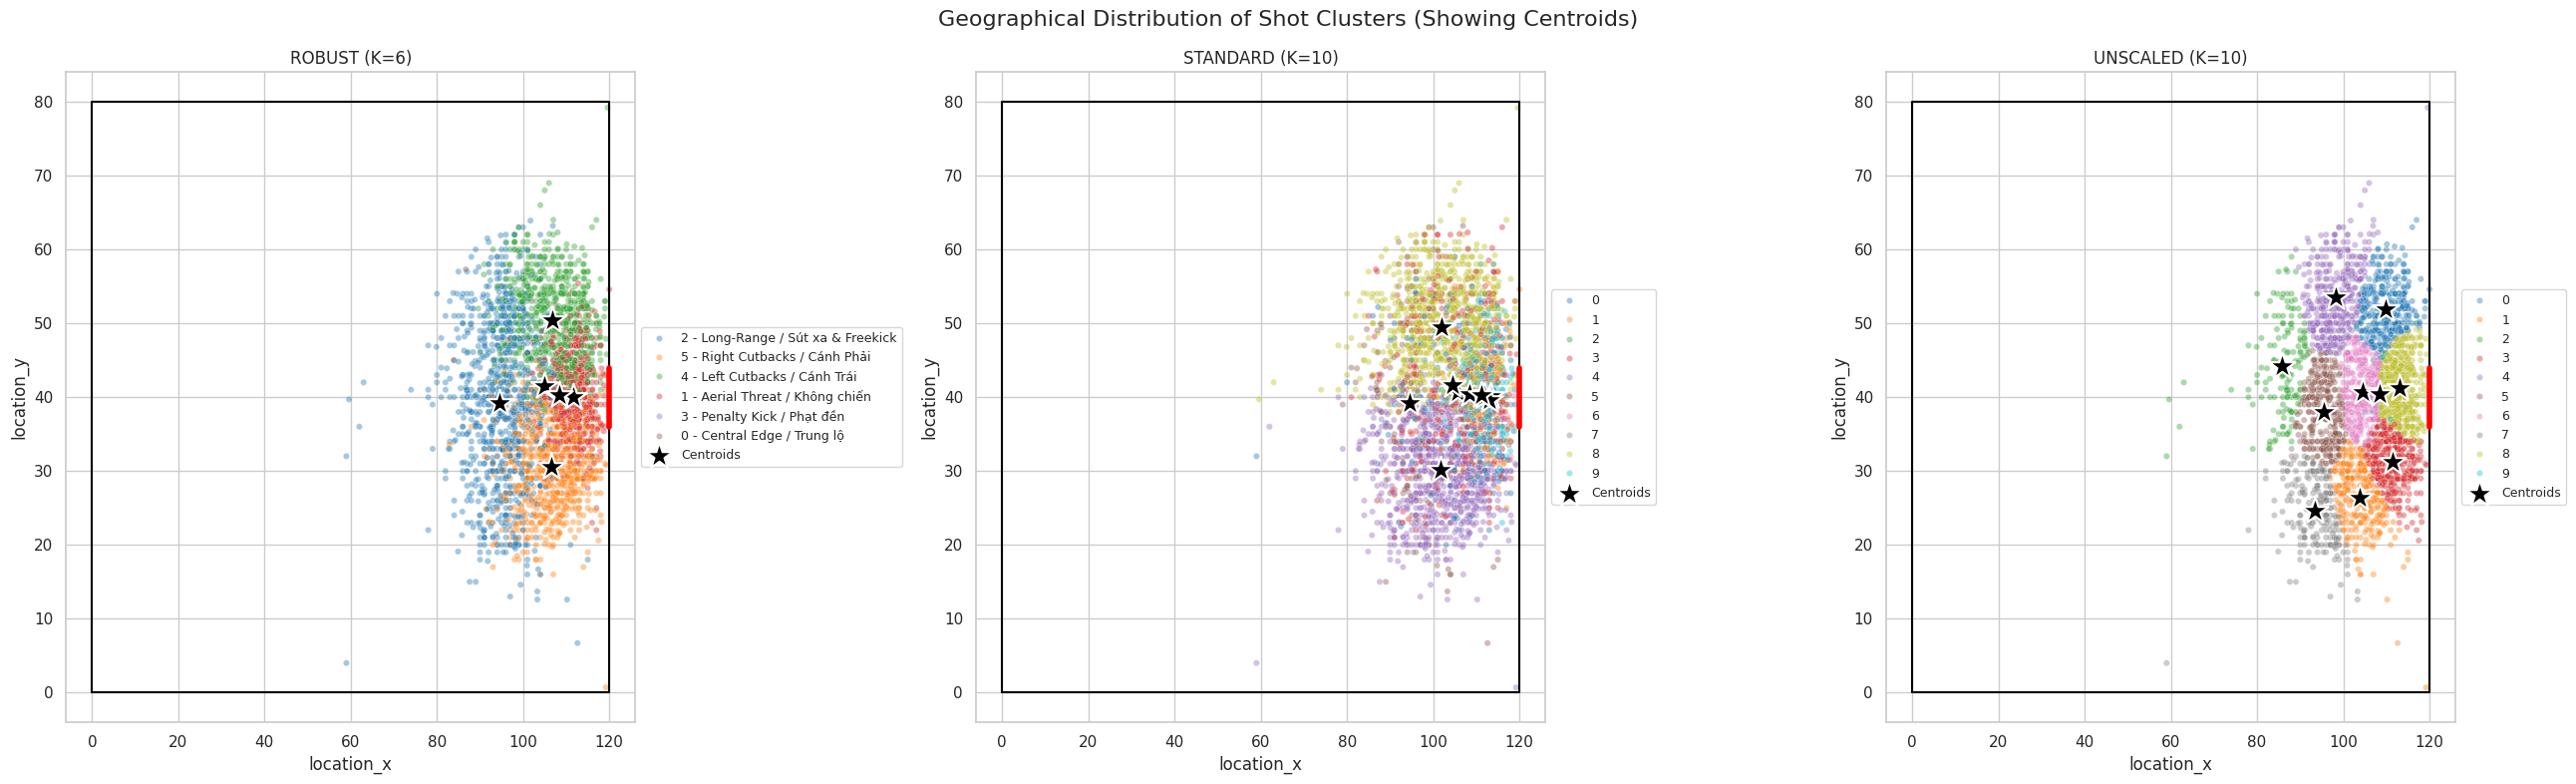

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(26, 8)) # Made it slightly wider to fit the text
fig.suptitle("Geographical Distribution of Shot Clusters (Showing Centroids)", fontsize=16)

# 1. Define our bilingual tactical names for the ROBUST K=6 clusters
robust_names = {
    0: "0 - Central Edge / Trung lộ",
    1: "1 - Aerial Threat / Không chiến",
    2: "2 - Long-Range / Sút xa & Freekick",
    3: "3 - Penalty Kick / Phạt đền",
    4: "4 - Left Cutbacks / Cánh Trái",
    5: "5 - Right Cutbacks / Cánh Phải"
}

# 2. Map the numbers (0-5) to the string names for the legend
named_labels_robust = pd.Series(labels_robust).map(robust_names)

# We will plot the 3 scaled versions
plot_configs = [
    # Notice we pass `named_labels_robust` here instead of `labels_robust`!
    (X_unscaled_features, named_labels_robust, "ROBUST (K=6)", centroids_physical_robust, axes[0]),
    (X_unscaled_features, labels_standard, "STANDARD (K=10)", centroids_physical_standard, axes[1]),
    (X_unscaled_features, labels_unscaled, "UNSCALED (K=10)", centroids_physical_unscaled, axes[2])
]

for X_data, labels, title, centroids_df, ax in plot_configs:
    # Plot the individual shots
    sns.scatterplot(
        x=X_data["location_x"],
        y=X_data["location_y"],
        hue=labels,
        palette="tab10",
        ax=ax,
        s=20,
        alpha=0.4 # Makes overlapping points clearer
    )

    # Plot the Centroids as large black stars
    ax.scatter(
        x=centroids_df["location_x"],
        y=centroids_df["location_y"],
        color="black",
        marker="*",
        s=400, # Large size
        edgecolor="white",
        linewidth=1.5,
        label="Centroids"
    )

    # Draw the penalty box lines for context
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
    ax.plot([120, 120], [36, 44], color="red", linewidth=4) # Goal line

    ax.set_title(title)

    # Move the legend slightly to avoid overlapping the plot data
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
plt.show()